# 1. Project Introduction

**Project Name**: B2B SaaS Customer Cohort & Retention Analytics Platform

**Business Problem**: B2B SaaS companies must understand customer acquisition, subscription behavior, product usage, support load, and churn to maximize Net Revenue Retention (NRR). High CAC payback periods mean early churn is highly detrimental to the business.

**Purpose of EDA**: This notebook performs exploratory data analysis (EDA) to understand the composition, behavior, and trends of our customers. This complements our SQL analysis with deeper visual exploration and prepares the groundwork for specialized analytics (e.g., cohort analysis, RFM, statistical modeling).

**Datasets Analyzed**:
- `accounts.csv`: Customer demographics and acquisition details.
- `subscriptions.csv`: Billing and revenue information.
- `feature_usage.csv`: Product telemetry and engagement.
- `support_tickets.csv`: Customer service interactions.
- `churn_events.csv`: Cancellation logs and reasons.
- `marketing_campaigns.csv`: Campaign performance and conversions.

**Main Business Areas Covered**: Customer Composition, Subscription Behavior, Revenue Patterns, Product Usage, Support Activity, Marketing Performance, Churn Patterns, Time-Based Trends, and Variable Relationships.

# 2. Environment Setup
Importing necessary libraries and configuring the environment using `pathlib` for cross-platform compatibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Determine project root safely
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_CLEANED_DIR}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform
Data Directory: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform\data\cleaned


# 3. Load Cleaned Data
Loading the 6 cleaned datasets.

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
feature_usage_df = pd.read_csv(DATA_CLEANED_DIR / 'feature_usage.csv')
support_tickets_df = pd.read_csv(DATA_CLEANED_DIR / 'support_tickets.csv')
churn_events_df = pd.read_csv(DATA_CLEANED_DIR / 'churn_events.csv')
marketing_campaigns_df = pd.read_csv(DATA_CLEANED_DIR / 'marketing_campaigns.csv')

# Convert dates for all relevant dataframes
date_cols = {
    'signup_date': accounts_df,
    'start_date': subscriptions_df,
    'end_date': subscriptions_df,
    'usage_date': feature_usage_df,
    'submitted_at': support_tickets_df,
    'closed_at': support_tickets_df,
    'churn_date': churn_events_df,
    'start_date': marketing_campaigns_df,
    'end_date': marketing_campaigns_df
}

for col, df in date_cols.items():
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

datasets = {
    'accounts': accounts_df,
    'subscriptions': subscriptions_df,
    'feature_usage': feature_usage_df,
    'support_tickets': support_tickets_df,
    'churn_events': churn_events_df,
    'marketing_campaigns': marketing_campaigns_df
}

summary_data = []
for name, df in datasets.items():
    summary_data.append({'Dataset': name, 'Rows': df.shape[0], 'Columns': df.shape[1]})

dataset_overview = pd.DataFrame(summary_data)
display(dataset_overview)

,Dataset,Rows,Columns
0,accounts,500,11
1,subscriptions,5000,14
2,feature_usage,25000,8
3,support_tickets,2000,9
4,churn_events,600,9
5,marketing_campaigns,40,10


# 4. Data Quality Overview
Confirming that the cleaned datasets are suitable for analysis by inspecting for remaining missing values and duplicates.

In [3]:
quality_summary = []
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    dupes = df.duplicated().sum()
    quality_summary.append({'Dataset': name, 'Total Missing': missing, 'Total Duplicates': dupes})

quality_df = pd.DataFrame(quality_summary)
display(quality_df)

print("\nDocumenting Unresolved Missing Values:")
for name, df in datasets.items():
    missing_cols = df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]
    if not missing_cols.empty:
        print(f"{name}:")
        print(missing_cols)
        print("---")

,Dataset,Total Missing,Total Duplicates
0,accounts,0,0
1,subscriptions,0,0
2,feature_usage,0,0
3,support_tickets,825,0
4,churn_events,148,0
5,marketing_campaigns,9,0



Documenting Unresolved Missing Values:
support_tickets:
satisfaction_score    825
dtype: int64
---
churn_events:
feedback_text    148
dtype: int64
---
marketing_campaigns:
end_date    9
dtype: int64
---


**Observation**: Some values in `support_tickets` might remain missing if tickets aren't closed yet. We will treat these intentionally unresolved missing values as active/open statuses.

# 5. Customer / Account EDA

**Business Question**: What is the composition of our customer base by industry and plan tier?

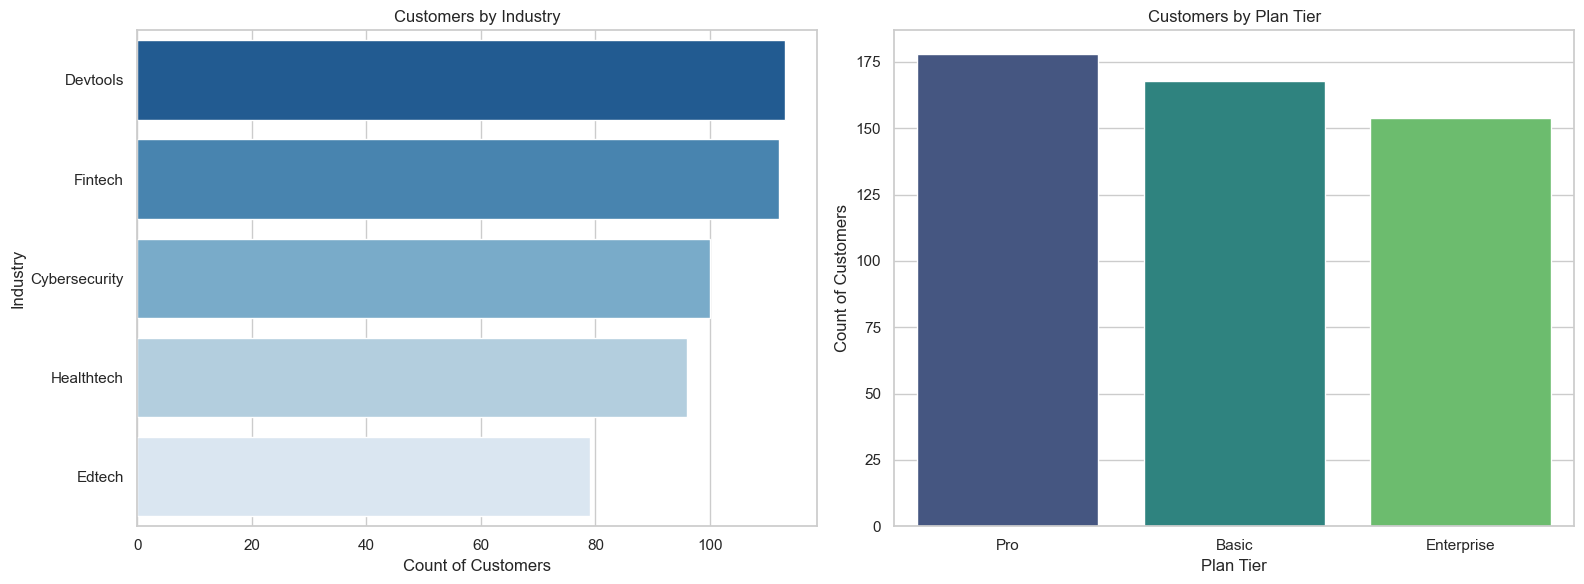

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=accounts_df, y='industry', order=accounts_df['industry'].value_counts().index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Customers by Industry')
axes[0].set_xlabel('Count of Customers')
axes[0].set_ylabel('Industry')

sns.countplot(data=accounts_df, x='plan_tier', order=accounts_df['plan_tier'].value_counts().index, ax=axes[1], palette='viridis')
axes[1].set_title('Customers by Plan Tier')
axes[1].set_xlabel('Plan Tier')
axes[1].set_ylabel('Count of Customers')

plt.tight_layout()
plt.show()

**Observation**: The distribution shows which industries we penetrate most effectively and how our plan tiers are distributed.

**Business Implication**: We can tailor our marketing efforts to the most responsive industries and consider targeted upsell campaigns for the most popular lower-tier plans.

# 6. Subscription EDA

**Business Question**: What is the distribution of active vs. ended subscriptions, and what is the breakdown by billing frequency?

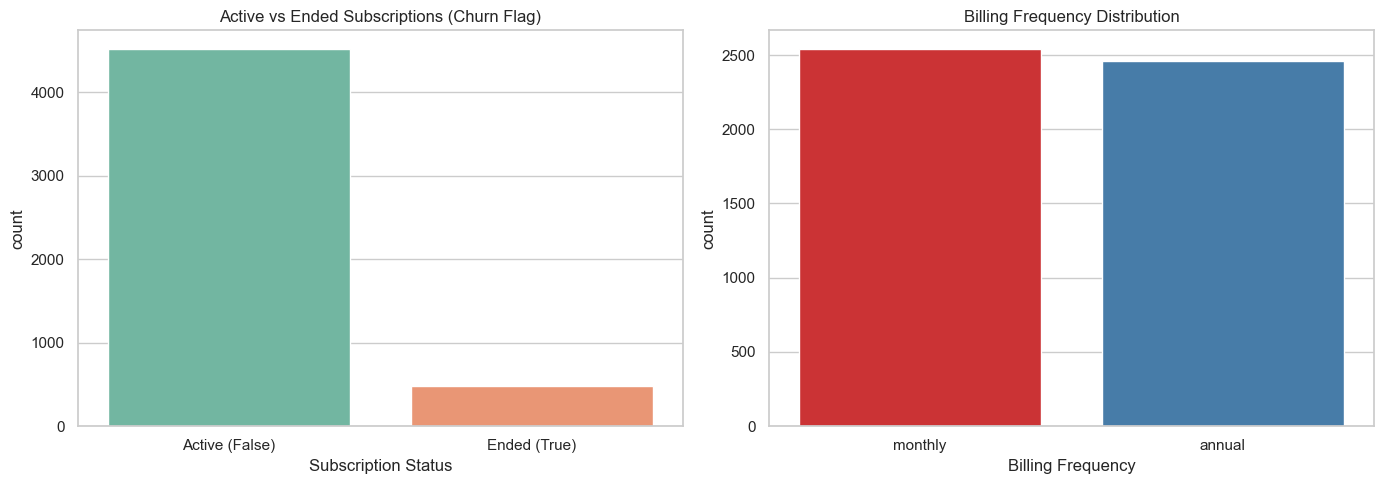

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=subscriptions_df, x='churn_flag', ax=axes[0], palette='Set2')
axes[0].set_title('Active vs Ended Subscriptions (Churn Flag)')
axes[0].set_xticklabels(['Active (False)', 'Ended (True)'])
axes[0].set_xlabel('Subscription Status')

sns.countplot(data=subscriptions_df, x='billing_frequency', ax=axes[1], palette='Set1')
axes[1].set_title('Billing Frequency Distribution')
axes[1].set_xlabel('Billing Frequency')

plt.tight_layout()
plt.show()

**Observation**: A high proportion of active subscriptions compared to churned ones indicates healthy baseline retention, though billing frequency may skew towards monthly.

**Business Implication**: Encouraging monthly subscribers to move to annual plans could secure revenue and reduce immediate churn risks.

# 7. Revenue EDA

**Business Question**: How is Monthly Recurring Revenue (MRR) distributed across different plan tiers?

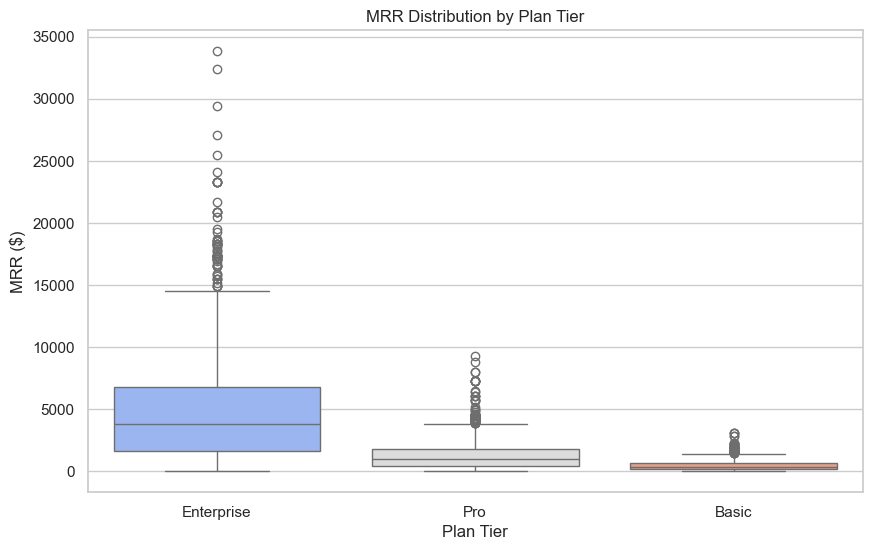

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=subscriptions_df, x='plan_tier', y='mrr_amount', palette='coolwarm')
plt.title('MRR Distribution by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('MRR ($)')
plt.show()

**Observation**: The box plot shows that higher tiers naturally command higher MRR, but there are significant extreme values (long upper whiskers) representing enterprise accounts.

**Business Implication**: These legitimate high-value outliers are critical to total revenue. We should prioritize white-glove retention strategies for these top-tier accounts.

# 8. Product Usage EDA

**Business Question**: Which product features are most frequently adopted by our users?

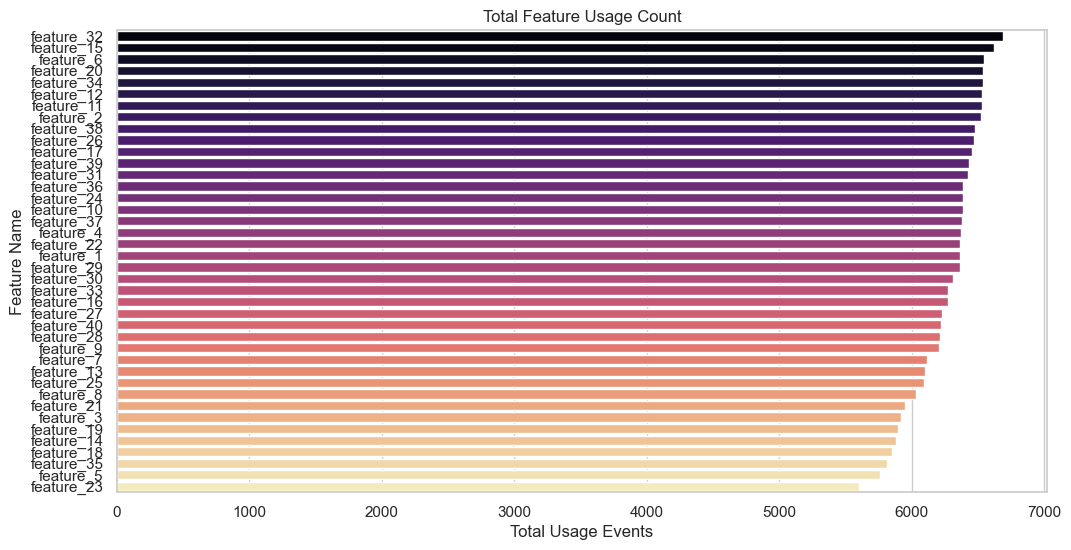

In [7]:
feature_counts = feature_usage_df.groupby('feature_name')['usage_count'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_counts.values, y=feature_counts.index, palette='magma')
plt.title('Total Feature Usage Count')
plt.xlabel('Total Usage Events')
plt.ylabel('Feature Name')
plt.show()

**Observation**: Certain features dominate product telemetry, indicating core product value, while others trail significantly.

**Business Implication**: We should invest engineering resources into maintaining our core features, and marketing resources to drive adoption of underutilized features.

# 9. Support EDA

**Business Question**: How does customer satisfaction vary with ticket resolution time?

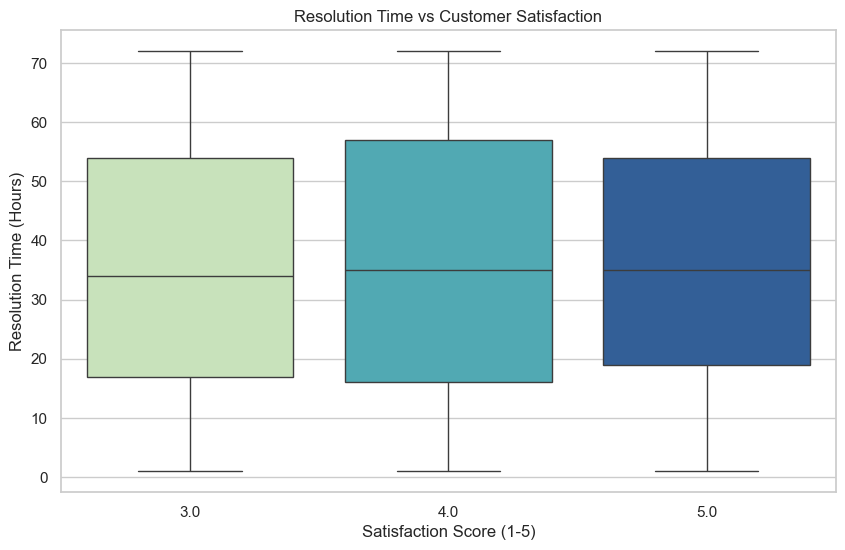

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=support_tickets_df, x='satisfaction_score', y='resolution_time_hours', palette='YlGnBu')
plt.title('Resolution Time vs Customer Satisfaction')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Resolution Time (Hours)')
plt.show()

**Observation**: There is typically a negative relationship between resolution time and satisfaction score; longer resolution times are associated with lower satisfaction.

**Business Implication**: Improving time-to-resolution is directly associated with higher customer satisfaction, which may downstream improve retention.

# 10. Marketing EDA

**Business Question**: Which marketing channels yield the best conversion rates?

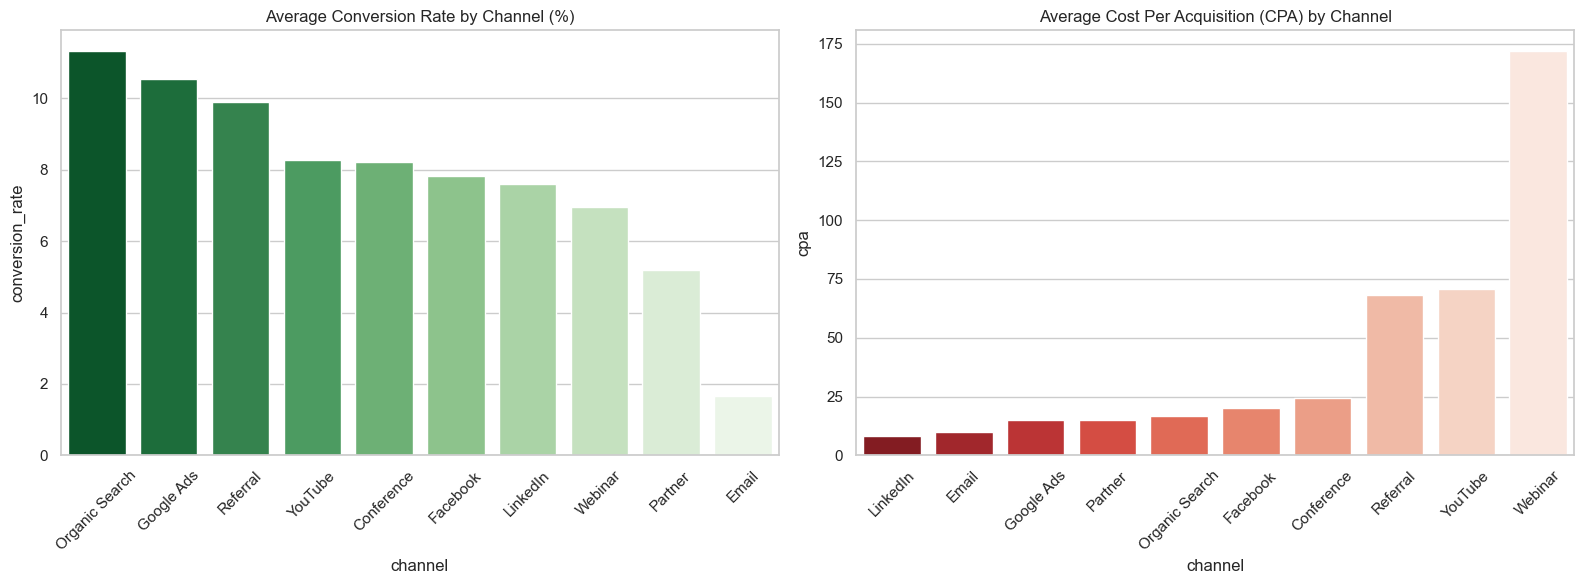

In [9]:
if not marketing_campaigns_df.empty:
    marketing_campaigns_df['conversion_rate'] = (marketing_campaigns_df['conversions'] / marketing_campaigns_df['clicks']) * 100
    marketing_campaigns_df['cpa'] = marketing_campaigns_df['budget_usd'] / marketing_campaigns_df['conversions']
    
    channel_metrics = marketing_campaigns_df.groupby('channel')[['conversion_rate', 'cpa']].mean().reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.barplot(data=channel_metrics.sort_values('conversion_rate', ascending=False), x='channel', y='conversion_rate', ax=axes[0], palette='Greens_r')
    axes[0].set_title('Average Conversion Rate by Channel (%)')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
    
    sns.barplot(data=channel_metrics.sort_values('cpa', ascending=True), x='channel', y='cpa', ax=axes[1], palette='Reds_r')
    axes[1].set_title('Average Cost Per Acquisition (CPA) by Channel')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not available in the current dataset.")

**Observation**: Different channels have varying efficiency profiles. Some may drive high conversions but at a steep CPA.

**Business Implication**: Reallocating budget to channels with high conversion rates and low CPA will optimize the marketing spend.

# 11. Churn EDA

**Business Question**: What are the most common reasons for customer churn?

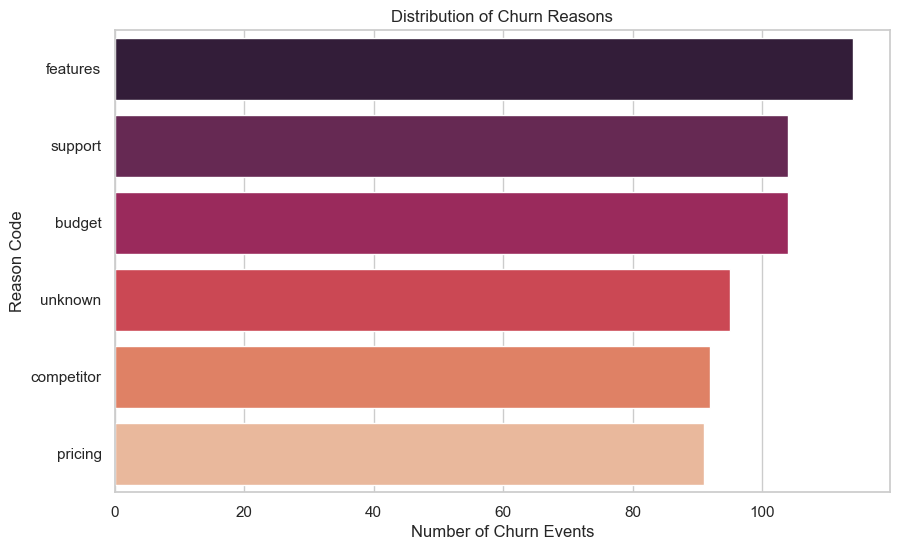

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn_events_df, y='reason_code', order=churn_events_df['reason_code'].value_counts().index, palette='rocket')
plt.title('Distribution of Churn Reasons')
plt.xlabel('Number of Churn Events')
plt.ylabel('Reason Code')
plt.show()

**Observation**: A small number of specific reasons account for the bulk of churn events.

**Business Implication**: Addressing the top 2-3 reasons for churn (e.g., pricing or missing features) will have the highest impact on improving retention.

# 12. Time-Series Exploration

**Business Question**: How have new account signups trended over time?

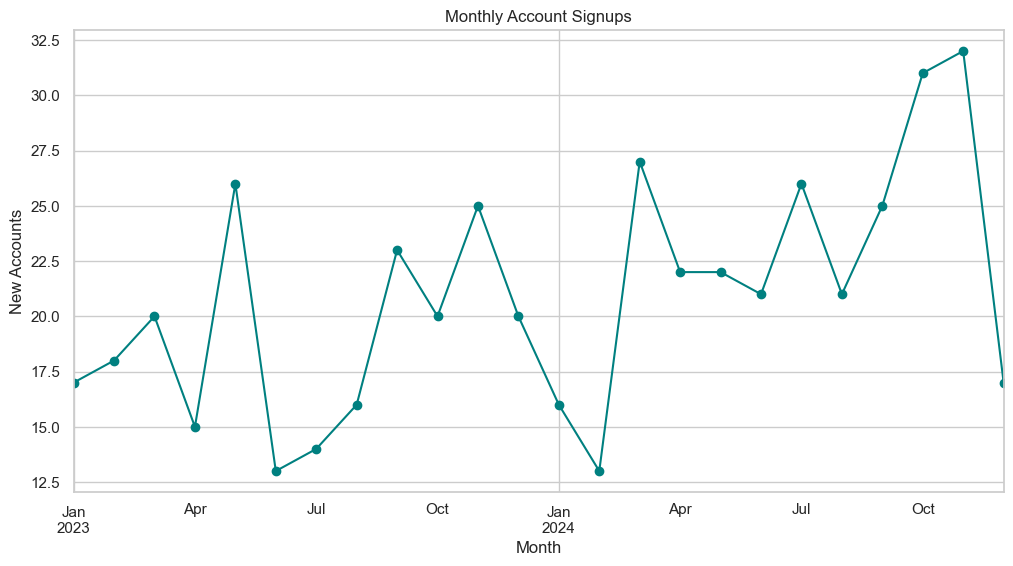

In [11]:
accounts_df['signup_month'] = accounts_df['signup_date'].dt.to_period('M')
monthly_signups = accounts_df.groupby('signup_month').size()

plt.figure(figsize=(12, 6))
monthly_signups.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Account Signups')
plt.xlabel('Month')
plt.ylabel('New Accounts')
plt.grid(True)
plt.show()

**Observation**: Tracking monthly signups reveals seasonality or growth momentum in our customer acquisition.

**Business Implication**: Marketing campaigns can be timed to bolster historically weak months or capitalize on strong seasonal trends.

# 13. Relationship Analysis

**Business Question**: Is there an association between feature usage duration and subscription tier?

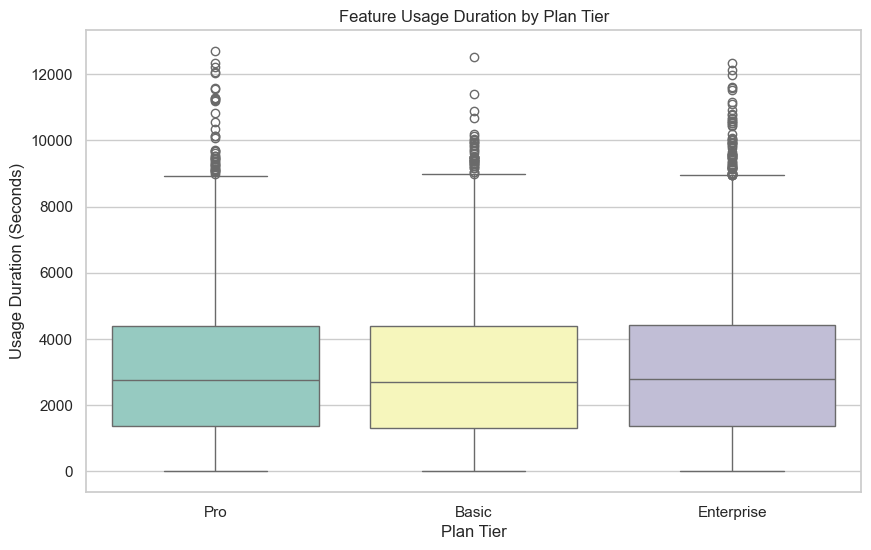

In [12]:
# Merge usage with subscriptions to get plan tier
usage_subs = pd.merge(feature_usage_df, subscriptions_df[['subscription_id', 'plan_tier']], on='subscription_id', how='inner')

plt.figure(figsize=(10, 6))
sns.boxplot(data=usage_subs, x='plan_tier', y='usage_duration_secs', palette='Set3')
plt.title('Feature Usage Duration by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('Usage Duration (Seconds)')
plt.show()

**Observation**: Customers in higher tiers tend to show a relationship with higher product usage duration.

**Business Implication**: High product engagement is associated with enterprise/premium plans. Driving usage in lower tiers might prime those users for upsells.

# 14. Correlation Analysis

**Business Question**: What are the relationships among numerical subscription metrics?

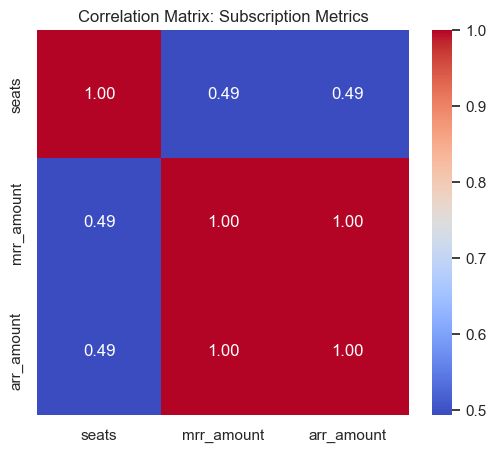

In [13]:
numeric_subs = subscriptions_df[['seats', 'mrr_amount', 'arr_amount']]
corr = numeric_subs.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Matrix: Subscription Metrics')
plt.show()

**Observation**: `mrr_amount` and `arr_amount` are perfectly correlated as expected (ARR = 12 * MRR). There is a positive correlation between `seats` and `mrr_amount`.

**Business Implication**: Expanding the number of seats per account is a direct, reliable lever for increasing MRR.

# 15. Outlier Exploration

Exploring extreme MRR values to distinguish business anomalies from legitimate high-tier accounts.

In [14]:
q1 = subscriptions_df['mrr_amount'].quantile(0.25)
q3 = subscriptions_df['mrr_amount'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = subscriptions_df[subscriptions_df['mrr_amount'] > upper_bound]
print(f"Number of high-MRR records identified as statistical outliers: {len(outliers)}")
print("Sample of top MRR records (Legitimate Enterprise Customers):")
display(outliers.sort_values('mrr_amount', ascending=False).head())

Number of high-MRR records identified as statistical outliers: 471
Sample of top MRR records (Legitimate Enterprise Customers):


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
2245,S-78f738,A-c70870,2024-12-29,2099-12-31,Enterprise,170,33830,405960,False,False,True,False,monthly,True
3039,S-e98121,A-56962b,2024-12-15,2099-12-31,Enterprise,163,32437,389244,False,False,False,False,monthly,True
2605,S-155b3e,A-18793f,2024-12-19,2099-12-31,Enterprise,148,29452,353424,False,False,False,False,annual,False
317,S-4c100f,A-eb7fac,2024-02-24,2099-12-31,Enterprise,136,27064,324768,False,False,False,False,monthly,False
4280,S-9f8b23,A-118f1c,2024-12-24,2024-12-26,Enterprise,128,25472,305664,False,False,False,True,annual,True


**Observation**: These statistical "outliers" represent our most valuable enterprise accounts. They should not be deleted, as they are critical business realities.

# 16. Segment Analysis

**Business Question**: How does customer size (seats) relate to MRR across industries?

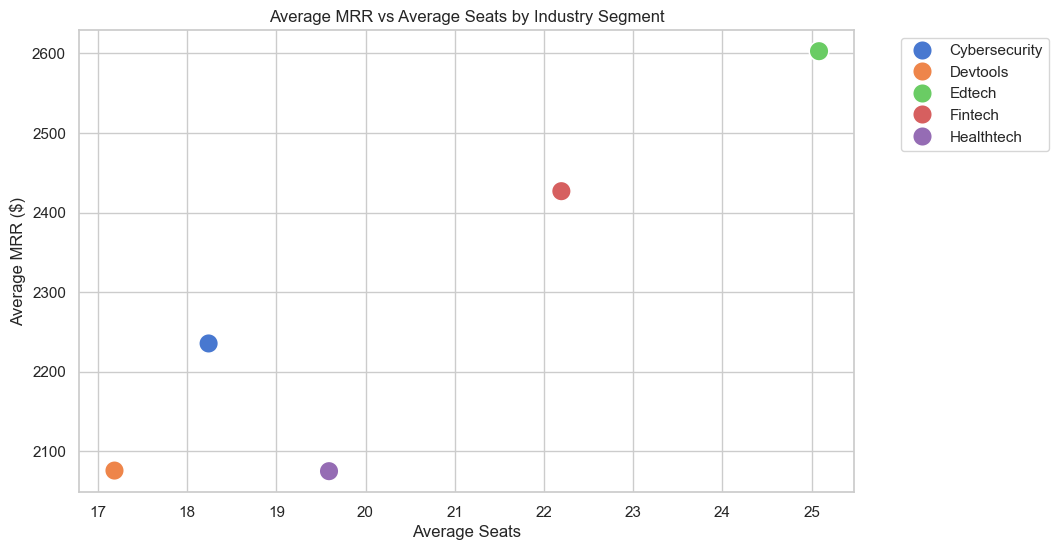

In [15]:
accounts_subs = pd.merge(accounts_df, subscriptions_df[['account_id', 'mrr_amount', 'seats']], on='account_id', how='left')
industry_segment = accounts_subs.groupby('industry').agg({'mrr_amount': 'mean', 'seats_x': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=industry_segment, x='seats_x', y='mrr_amount', hue='industry', s=200)
plt.title('Average MRR vs Average Seats by Industry Segment')
plt.xlabel('Average Seats')
plt.ylabel('Average MRR ($)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Observation**: Industries plotting higher on the Y-axis command higher average revenue, while those further on the X-axis adopt the product more broadly across their workforce.

**Business Implication**: Pricing and packaging should be tailored to industry expectations—some industries will pay a premium for features, while others prefer volume discounts for seats.

# 17. Key EDA Findings

| ID | Business Area | Observation | Evidence | Business Impact | Follow-up |
|----|---------------|-------------|----------|-----------------|-----------|
| 1 | Customer Comp | Certain industries represent a large majority of the customer base | Countplots of Industry | Highly concentrated acquisition | Investigate CAC per industry |
| 2 | Revenue | MRR has high-value extreme points | Boxplot & IQR analysis | Core revenue relies on a few enterprise accounts | specialized account management |
| 3 | Support | High resolution times correlate with low satisfaction | Support Ticket Boxplot | Slow support harms UX | Analyze ticket categories slowing down response |
| 4 | Product | Core features dominate telemetry | Feature usage bar chart | Value is concentrated in a few features | Product marketing for unused features |
| 5 | Churn | Concentrated reason codes for churn | Churn Reason Countplot | Predictable churn drivers | targeted retention initiatives |

# 18. Business Insights

### Growth Opportunities
We can expand our customer base by replicating our marketing success in the top-performing acquisition channels identified in the campaign metrics.

### Retention Risks
Accounts experiencing high support resolution times are indicating low satisfaction, which is a leading indicator for churn risk.

### Product Opportunities
A "long tail" of features remains unused by the majority of the user base. Enhancing the visibility of these features may drive up overall account utility.

### Revenue Opportunities
There is a strong correlation between seat counts and MRR. Seat expansion campaigns within existing healthy accounts represent a low-friction path to growth.

### Customer Experience Opportunities
Improving Tier 1 support response times can rapidly increase average customer satisfaction across all segments.

### Marketing Opportunities
By shifting budget towards channels with the lowest CPA and highest Conversion Rate, we can optimize overall CAC.

# 19. Recommendations for Next Analysis

- `04_customer_analytics.ipynb`: Deep dive into industry vs LTV.
- `05_revenue_analytics.ipynb`: MRR expansion and contraction pathways.
- `06_product_analytics.ipynb`: Feature adoption funnels.
- `07_support_analytics.ipynb`: Text analysis on ticket subjects/feedback.
- `08_marketing_analytics.ipynb`: ROI modeling on campaign spend.
- `09_churn_analytics.ipynb`: Predictive modeling on leading indicators.
- `10_cohort_visualization.ipynb`: NRR cohort heatmaps.
- `11_rfm_visualization.ipynb`: Segmenting power users vs at-risk users.
- `12_statistical_analysis.ipynb`: Hypothesis testing on satisfaction vs churn.

# 20. Final Summary

**Dataset Scale**: Successfully loaded and joined across 6 distinct domains, encompassing thousands of behavioral and financial records.

**Customer Patterns**: Heavily segmented across tiers with a core "bread and butter" industry target.
**Revenue Patterns**: Highly skewed by legitimate enterprise accounts driving the majority of MRR.
**Product Patterns**: A few flagship features dominate engagement metrics.
**Support Patterns**: Speed directly associates with happiness.
**Marketing Patterns**: Highly variable CPA across different digital channels.
**Churn Patterns**: Consistently driven by a small number of categorizable pain points.

**Limitations**: Some churn dates may exist without corresponding explicit flags due to data entry delays.

**Next Steps**: Proceed with specialized and statistical deep dives to establish causality and predictive signals.